In [1]:
import os
path = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(path)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset import ECGDataset
import torch


In [2]:
BASE_DIR = Path(os.getcwd())
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [3]:
import matplotlib.pyplot as plt

def plot_ecg_window(x, leads=None, title=None):
    """
    x: torch.Tensor or np.ndarray, shape (n_channels, window_size)
    leads: list of lead names for labeling
    """
    if isinstance(x, torch.Tensor):
        x = x.numpy()

    n_channels, window_size = x.shape
    time = np.arange(window_size)

    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(time, x[i], linewidth=1)
        if leads:
            ax.set_ylabel(leads[i])
        ax.grid(True, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Samples")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [4]:
preprocessed_data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_split_path = os.path.join(DATA_DIR, 'input', 'experiment', 'leads_MLII_V1_tst0.25_rd42.json')

# Double channel (MLII + V1)
ds2 = ECGDataset(preprocessed_data_dir, window_size=1000,  json_file_path=json_split_path, mode="sliding")
print(next(iter(ds2)).shape)  # torch.Size([2, 500])

Loading data for 30 patients from 'train' split...
torch.Size([2, 1000])


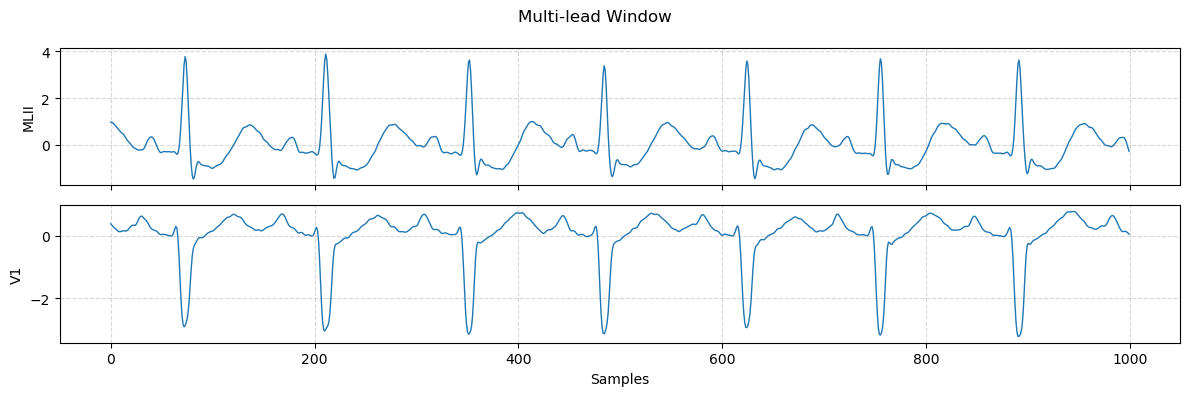

In [5]:
x = ds2[50]

plot_ecg_window(x, leads=["MLII", "V1"], title="Multi-lead Window")
